In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal

In [18]:
class state(TypedDict):
    name:str
    marks:float
    attendance:int
    status:str
    grade:str
    

In [19]:
#defining nodes
def get_details(state: state) -> state:
    return state

In [20]:
def check_attendance(state: state) -> state:
    if state['attendance'] < 75:
        status = state['status'] = 'Fail'
    else:
        status = state['status'] = 'Pass'
    return state

In [21]:
def check_marks(state: state) -> state:
    if state['marks'] >= 90:
        grade = state['grade'] = 'A'
    elif state['marks'] >= 80:
        grade = state['grade'] = 'B'
    elif state['marks'] >= 70:
        grade = state['grade'] = 'C'
    else:
        grade = state['grade'] = 'D'
    return state

In [22]:
#failed student
def fail(state: state):
    return state

In [23]:
def check_condition(state: state) -> Literal['fail', 'check_marks']:
    if state['status'] == 'Fail':
        return 'fail'
    return "check_marks"

In [24]:
graph = StateGraph(state)

graph.add_node("get_details", get_details)
graph.add_node("check_attendance", check_attendance)
graph.add_node("check_marks", check_marks)
graph.add_node("fail", fail)

graph.add_edge(START, "get_details")
graph.add_edge("get_details", "check_attendance")

#graph.add_conditional_edges(source_node,router_function,path_map) source_node → kis node ke baad decision lena hai router_function → next node ka naam batayegapath_map → router ke return value ko actual node se map karega (optional, lekin bahut useful)
graph.add_conditional_edges("check_attendance",check_condition, {"fail": "fail", "check_marks": "check_marks"}) 
graph.add_edge("check_marks", END)
graph.add_edge("fail", END)

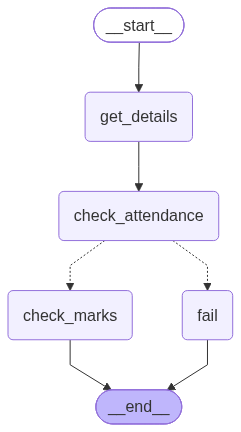

In [25]:
workflow = graph.compile()
workflow

In [26]:
initial_state = {
    "name": "Rahul",
    "marks": 85,
    "attendance": 90,
    "status": "",
    "grade": ""
}

In [27]:
result = workflow.invoke(initial_state)

print(result)

{'name': 'Rahul', 'marks': 85, 'attendance': 90, 'status': 'Pass', 'grade': 'B'}


┌──────────────────────────────────────────────────────────────┐
│               LangGraph Errors (Quick Notes)                 │
├──────────────────────────────────────────────────────────────┤
│ Error 1: Wrong Method                                        │
│ • add_conditional_edge() ❌                                  │
│ • add_conditional_edges() ✅                                 │
├──────────────────────────────────────────────────────────────┤
│ Error 2: Wrong Source Node                                   │
│ • Conditional edge is added from the decision node.          │
│ • Not from the router function.                              │
├──────────────────────────────────────────────────────────────┤
│ Error 3: Wrong Router Return                                 │
│ • Router → Returns Next Node Name (String).                  │
│ • return state ❌                                             │
│ • return "fail" ✅                                            │
├──────────────────────────────────────────────────────────────┤
│ Error 4: Wrong Node Return                                   │
│ • Node → Returns Updated State.                              │
│ • return True ❌                                              │
│ • return "Fail" ❌                                            │
│ • return state ✅                                             │
├──────────────────────────────────────────────────────────────┤
│ Error 5: Missing/Wrong Path Mapping                          │
│ • Router Output → Node Mapping                               │
│ • {"fail":"fail","check_marks":"check_marks"}                │
├──────────────────────────────────────────────────────────────┤
│ Error 6: END Not Connected                                   │
│ • Every final node must connect to END.                      │
│ • graph.add_edge("fail", END)                                │
│ • graph.add_edge("check_marks", END)                         │
├──────────────────────────────────────────────────────────────┤
│ Error 7: Graph Not Compiled                                  │
│ • Compile before invoke.                                     │
│ • workflow = graph.compile()                                 │
│ • workflow.invoke(initial_state)                             │
└──────────────────────────────────────────────────────────────┘